# 04 · Posterior reconstruction + uncertainty

Run NUTS over `z`, decode each posterior sample, and form the per-pixel
**mean** and **std**. The std map is the uncertainty. Keep `latent_dim` ≈
128–256 so the sampler mixes.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from mrigen import metrics, viz
from mrigen.data import FastMRISlices
from mrigen.evaluate import measure
from mrigen.masks import equispaced_mask
from mrigen.recon.classical import zero_filled
from mrigen.recon.vae_numpyro import reconstruct_posterior

SIGMA = 0.01

# NUTS cost is up to 2**max_tree_depth - 1 decoder evaluations *per sample*, so
# on a laptop CPU the tree depth is the knob that decides whether this notebook
# takes two minutes or two hours. Depth 7 mixes acceptably in 128 dimensions;
# raise it (and the sample count) on the GPU server and re-check r_hat.
ON_GPU = jax.default_backend() == 'gpu'
NUM_SAMPLES = 400 if ON_GPU else 150
NUM_WARMUP = 400 if ON_GPU else 150
TREE_DEPTH = 10 if ON_GPU else 7
print(f"backend {jax.default_backend()}: {NUM_WARMUP} warm-up + {NUM_SAMPLES} samples, "
      f"max_tree_depth {TREE_DEPTH}")

backend cpu: 150 warm-up + 150 samples, max_tree_depth 7


In [2]:
from mrigen.train_vae import load_model

vae = load_model('../checkpoints/vae_128.eqx', latent_dim=128)

# Held-out volume, central slice, R = 8: uncertainty is only interesting where
# the data is genuinely ambiguous, and at R = 4 the ACS band pins most of the
# image down.
test = FastMRISlices('../data/processed', split='val')
x = jnp.asarray(test[len(test) // 2])
mask = equispaced_mask((128, 128), acceleration=8)
y = measure(x, mask, SIGMA, jax.random.PRNGKey(8))
print(f"held-out slice from {test.volumes}, "
      f"R = {float(mask.size / mask.sum()):.2f}x effective")

held-out slice from ['file1000593'], R = 5.12x effective


In [3]:
import time

t0 = time.perf_counter()
post = reconstruct_posterior(y, mask, vae.decoder, vae.latent_dim, sigma=SIGMA,
                             num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES,
                             max_tree_depth=TREE_DEPTH)
print(f"\nNUTS took {time.perf_counter() - t0:.0f}s")

# Did it mix? r_hat needs several chains to mean much, but the effective sample
# size per latent dimension is informative from one chain: if n_eff is a few
# percent of NUM_SAMPLES, the std map is noise, not uncertainty.
post['mcmc'].print_summary(exclude_deterministic=True)

gt = np.asarray(x)
x_mean, x_std = np.asarray(post['mean']), np.asarray(post['std'])
x_zf = np.asarray(zero_filled(y, mask))

print(f"\n{'method':<22} {'PSNR (dB)':>10} {'SSIM':>7}")
for name, r in (('zero-filled', x_zf), ('posterior mean', x_mean)):
    print(f"{name:<22} {metrics.psnr(gt, r, data_range=1.0):>10.2f} "
          f"{metrics.ssim(gt, r, data_range=1.0):>7.3f}")
print(f"\nposterior std: mean {x_std.mean():.4f}  max {x_std.max():.4f}")
print(f"actual |error|: mean {np.abs(x_mean - gt).mean():.4f}  "
      f"max {np.abs(x_mean - gt).max():.4f}")
print(f"sample diversity (mean pairwise 1-SSIM): "
      f"{metrics.diversity(np.asarray(post['samples'][:16])):.3f}")

  0%|          | 0/300 [00:00<?, ?it/s]

warmup:   5%|▌         | 15/300 [00:04<01:19,  3.57it/s, 1 steps of size 9.19e-04. acc. prob=0.60]

warmup:   5%|▌         | 15/300 [00:19<01:19,  3.57it/s, 1 steps of size 6.94e-04. acc. prob=0.65]

warmup:   8%|▊         | 23/300 [00:20<04:46,  1.04s/it, 7 steps of size 1.35e-03. acc. prob=0.67]

warmup:   8%|▊         | 24/300 [00:21<04:39,  1.01s/it, 7 steps of size 2.58e-03. acc. prob=0.68]

...

sample: 100%|█████████▉| 299/300 [53:48<00:11, 11.12s/it, 127 steps of size 7.35e-03. acc. prob=0.88]

sample: 100%|██████████| 300/300 [54:00<00:00, 11.10s/it, 127 steps of size 7.35e-03. acc. prob=0.88]

sample: 100%|██████████| 300/300 [54:00<00:00, 10.80s/it, 127 steps of size 7.35e-03. acc. prob=0.88]


NUTS took 2581s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
      z[0]     -1.83      0.29     -1.69     -2.27     -1.51      3.55      2.01
      z[1]      1.12      0.08      1.09      1.02      1.25      3.73      2.03
      z[2]     -1.01      0.33     -0.92     -1.58     -0.58      7.47      1.23
      z[3]     -1.92      0.54     -1.78     -2.83     -1.28      2.94      2.49
      z[4]     -3.25      0.68     -3.59     -4.00     -2.25      3.02      2.44
      z[5]     -2.39      0.24     -2.30     -2.79     -2.10      3.89      1.92
      z[6]     -2.11      0.56     -1.80     -3.07     -1.56      3.66      1.68
      z[7]     -2.84      0.15     -2.83     -3.10     -2.60     12.31      1.04
      z[8]      0.08      0.46      0.17     -0.30      0.58      6.04      1.39
      z[9]     -5.46      0.48     -5.32     -5.87     -5.09      9.51      1.10
     z[10]     -1.44      0.42     -1.25     -2.05     -1.01      3.52      1.91
     z[11]

sample:  93%|█████████▎| 279/300 [1:07:07<04:11, 11.96s/it, 127 steps of size 2.83e-02. acc. prob=0.90]

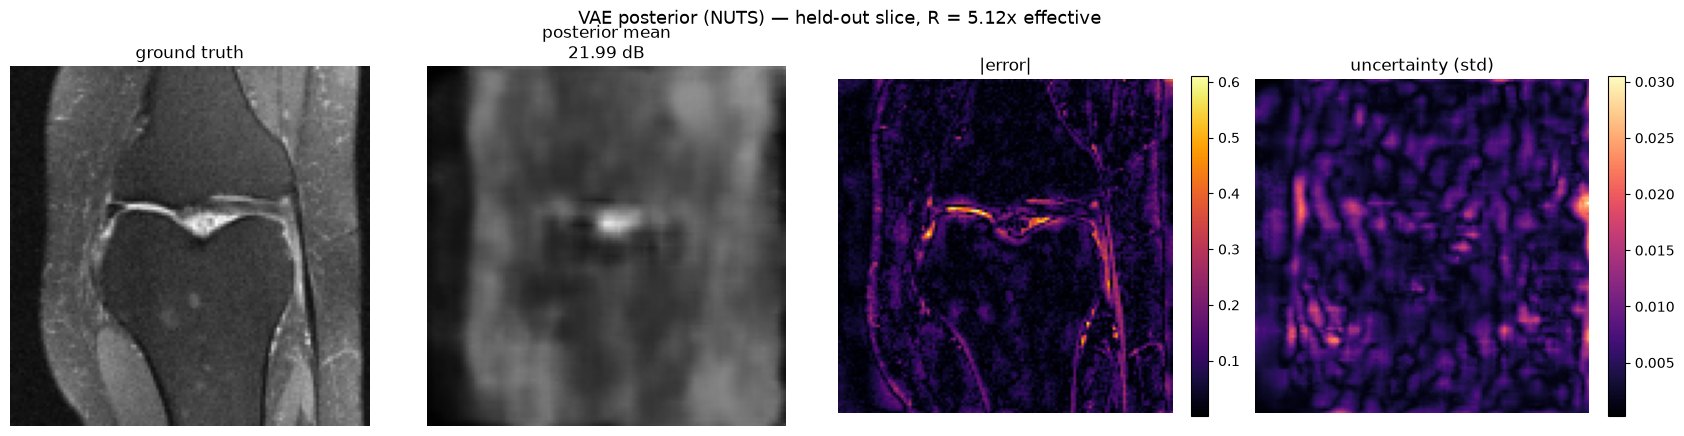

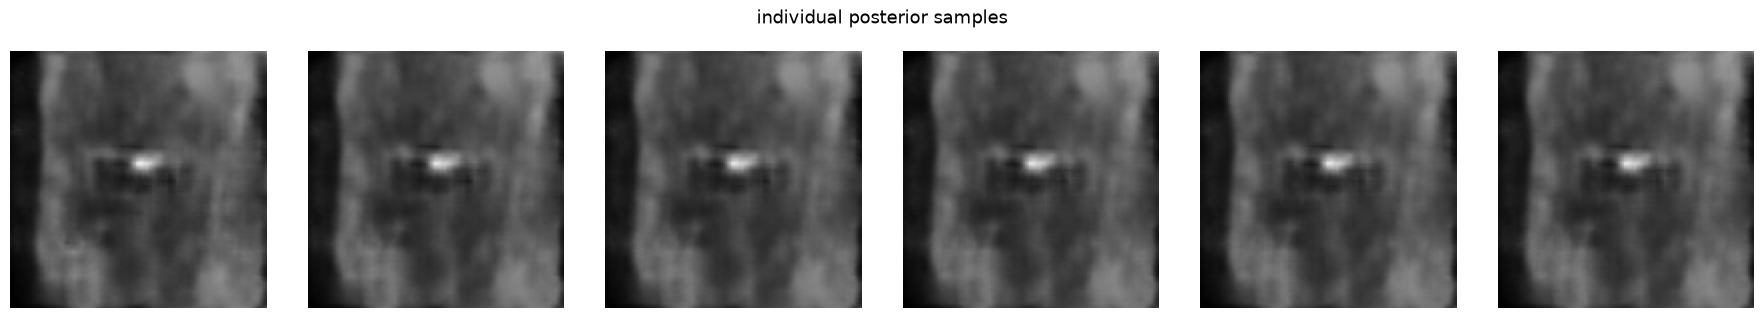

In [4]:
# The headline figure: ground truth | posterior mean | |error| | uncertainty.
# The last two panels are the point of the whole project — if the std map lights
# up where the error map does, the uncertainty is telling you something true.
fig, ax = plt.subplots(1, 4, figsize=(17, 4.4))
viz.show_image(gt, ax[0], title='ground truth', vmin=0, vmax=1)
viz.show_image(x_mean, ax[1], vmin=0, vmax=1,
               title=f"posterior mean\n{metrics.psnr(gt, x_mean, data_range=1.0):.2f} dB")
im2 = viz.show_error(gt, x_mean, ax[2])
fig.colorbar(im2, ax=ax[2], fraction=0.046)
im3 = viz.show_uncertainty(x_std, ax[3])
fig.colorbar(im3, ax=ax[3], fraction=0.046)
fig.suptitle(f"VAE posterior (NUTS) — held-out slice, "
             f"R = {float(mask.size / mask.sum()):.2f}x effective", fontsize=13)
fig.tight_layout()
fig.savefig('recon_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

# A few individual posterior samples: what the posterior thinks is possible.
fig, ax = plt.subplots(1, 6, figsize=(18, 3.2))
step = max(1, len(post['samples']) // 6)
for a, s in zip(ax, np.asarray(post['samples'])[::step]):
    viz.show_image(s, a, vmin=0, vmax=1)
fig.suptitle('individual posterior samples', fontsize=13)
fig.tight_layout()
plt.show()

err = np.abs(x_mean - gt)
s, e = metrics.calibration_curve(err, x_std, n_bins=12)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot(s, e, 'o-', label='measured')
# For Gaussian errors E|err| = sqrt(2/pi) * std, so that — not slope 1 — is the
# line a perfectly calibrated method would sit on.
lim = max(s.max(), e.max()) * 1.05
ax.plot([0, lim], [0, np.sqrt(2 / np.pi) * lim], 'k--',
        label=r'perfect calibration ($\sqrt{2/\pi}\,\sigma$)')
ax.set_xlabel('predicted std'); ax.set_ylabel('mean |error|')
ax.set_title('calibration, held-out slice')
ax.legend()
fig.tight_layout()
fig.savefig('calibration_nb04.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = e.mean() / (np.sqrt(2 / np.pi) * s.mean())
print(f"mean |error| / predicted  = {ratio:.1f}x")
print("Above 1 means the posterior is overconfident: the decoder cannot represent the\n"
      "held-out slice exactly, and the model has no term for 'my prior cannot draw this\n"
      "image', so that error never shows up in the std. Say this out loud in the talk —\n"
      "it is the honest limitation of a VAE prior, not a bug in the sampler.")

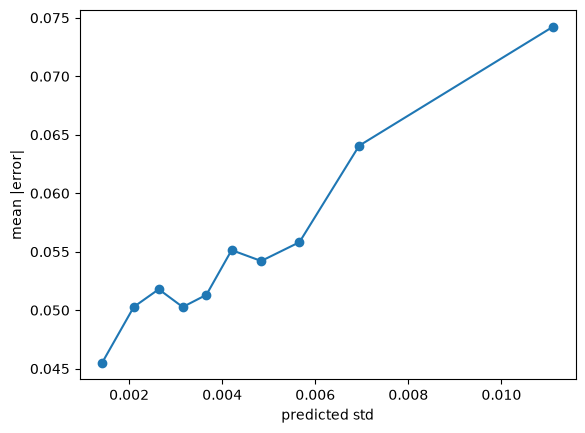

In [5]:
import numpy as np
err = np.abs(np.asarray(post['mean']) - np.asarray(x))
s, e = metrics.calibration_curve(err, np.asarray(post['std']))
plt.plot(s, e, 'o-'); plt.xlabel('predicted std'); plt.ylabel('mean |error|'); plt.show()